In [27]:
# %% [markdown]
# # Clasificación de sismicidad volcánica mediante Frequency Index (FI)
# Basado en Song & Tan (2025), JGR Solid Earth

# %% [markdown]
# ## 1. Importaciones y configuración

# %%
import json
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from obspy import read, read_inventory, UTCDateTime
from obspy.geodetics import gps2dist_azimuth
from obspy.signal.util import next_pow_2
from scipy.signal import find_peaks
from scipy.stats import gaussian_kde

warnings.filterwarnings("ignore")

In [28]:
# Parámetros del volcán y rutas
VOLCANO = {
    "name": "pavlof_2021",
    "lat": 55.4173,
    "lon": -161.8937,
}

BASE_DIR = Path("/home/elizabeth/soft/src/QuickQuake")
DATA_DIR = BASE_DIR / "data"
MERGED_DIR = DATA_DIR / "merged"

PATHS = {
    "data_base": DATA_DIR,
    "catalog_csv": MERGED_DIR / "output" / "GAMMA_hypodd_catalog_qcfiltered.csv",
    "picks_csv": MERGED_DIR / "gammapicks_id.csv",
    "stations_json": MERGED_DIR / "input" / "GAMMA_station_list.json",
    "inventory_xml": MERGED_DIR / "input" / "stations_merged.xml",
    "output_csv": MERGED_DIR / "output" / "GAMMA_hypodd_catalog_qcfiltered_FI.csv",
    "output_dir": MERGED_DIR / "output" / "fi_outputs",
}

PATHS["output_dir"].mkdir(parents=True, exist_ok=True)

# Filtros y ventanas (igual que en el script original)
FILTERS = {
    "event_radius_km": 100.0,
    "station_max_dist_km": 67.0, # criterio práctico, no réplica exacta de Song & Tan
    "min_stations": 2,
    "snr_threshold": 2.0,
}

WINDOWS = {
    "p_rel_start_s": -1.0,
    "p_win_len_s": 7.0,
    "pre_pick_s": 5.0,
    "post_pick_s": 25.0,
    "noise_win_s": 5.0,
}


In [29]:
# 2. Funciones auxiliares (distancias, carga de datos)

# %%
def horizontal_distance_km(lat1, lon1, lat2, lon2):
    dist_m, _, _ = gps2dist_azimuth(lat1, lon1, lat2, lon2)
    return dist_m / 1000.0

def get_hypocentral_distances(stations_df, ev_lat, ev_lon, ev_depth_km):
    stations_df = stations_df.copy()
    if "elev_km" not in stations_df.columns:
        stations_df["elev_km"] = 0.0
    hypo_distances = []
    for _, sta in stations_df.iterrows():
        dh_km = horizontal_distance_km(ev_lat, ev_lon, float(sta["lat"]), float(sta["lon"]))
        dz_km = ev_depth_km + float(sta["elev_km"])
        d3_km = np.sqrt(dh_km**2 + dz_km**2)
        hypo_distances.append(d3_km)
    stations_df["hypo_km"] = hypo_distances
    distance_map = dict(zip(stations_df["sta_id"], stations_df["hypo_km"]))
    return distance_map, stations_df

def filter_catalog_by_radius(df, volcano, radius_km, lat_col="latitude", lon_col="longitude"):
    out = df.copy()
    out["r_km"] = [
        horizontal_distance_km(lat, lon, volcano["lat"], volcano["lon"])
        for lat, lon in zip(out[lat_col], out[lon_col])
    ]
    out["inside_radius"] = out["r_km"] <= radius_km
    out_filtered = out[out["inside_radius"]].copy().reset_index(drop=True)
    return out, out_filtered

def infer_catalog_columns(df):
    colmap = {}
    candidates = {
        "time": ["datetime", "time", "origin_time"],
        "latitude": ["latitude", "lat"],
        "longitude": ["longitude", "lon"],
        "depth_km": ["depth_km", "depth"],
        "event_id": ["event_id", "id"],
        "magnitude": ["mag", "magnitude"],
    }
    for key, options in candidates.items():
        found = None
        for col in options:
            if col in df.columns:
                found = col
                break
        colmap[key] = found
    missing_required = [k for k in ["time", "latitude", "longitude"] if colmap[k] is None]
    if missing_required:
        raise ValueError(
            f"Catalog is missing required columns: {missing_required}. "
            f"Available columns: {list(df.columns)}"
        )
    return colmap

def load_catalog(catalog_csv):
    catalog = pd.read_csv(catalog_csv)
    colmap = infer_catalog_columns(catalog)
    catalog[colmap["time"]] = pd.to_datetime(
        catalog[colmap["time"]], utc=True, errors="coerce"
    )
    catalog = catalog.dropna(subset=[colmap["time"]]).reset_index(drop=True)
    return catalog, colmap

def load_picks(picks_csv):
    picks = pd.read_csv(picks_csv)
    if "timestamp" not in picks.columns:
        raise ValueError("The picks file must contain a 'timestamp' column.")
    picks["timestamp"] = pd.to_datetime(picks["timestamp"], utc=True, errors="coerce")
    picks = picks.dropna(subset=["timestamp"]).reset_index(drop=True)
    if "id" in picks.columns:
        id_parts = picks["id"].astype(str).str.split(".", expand=True)
        if id_parts.shape[1] >= 2:
            picks["net"] = id_parts[0]
            picks["sta"] = id_parts[1]
    if "net" in picks.columns and "sta" in picks.columns:
        picks["sta_id"] = picks["net"].astype(str) + "." + picks["sta"].astype(str)
    else:
        raise ValueError("Could not build 'sta_id'. Need either 'id' or both 'net' and 'sta' columns.")
    return picks

def load_stations(stations_json):
    with open(stations_json, "r") as f:
        stations_raw = json.load(f)
    stations_list = []
    for code, values in stations_raw.items():
        parts = code.split(".")
        net = parts[0] if len(parts) > 0 else ""
        sta = parts[1] if len(parts) > 1 else ""
        sta_id = f"{net}.{sta}" if net and sta else code
        elev_m = None
        if "elevation(m)" in values:
            elev_m = values["elevation(m)"]
        elif "elev_m" in values:
            elev_m = values["elev_m"]
        elif "elevation_m" in values:
            elev_m = values["elevation_m"]
        elev_km = float(elev_m) / 1000.0 if elev_m is not None else 0.0
        stations_list.append({
            "sta_id": sta_id,
            "net": net,
            "sta": sta,
            "lat": values.get("latitude"),
            "lon": values.get("longitude"),
            "elev_km": elev_km,
        })
    stations = pd.DataFrame(stations_list)
    required_cols = ["sta_id", "lat", "lon", "elev_km"]
    for col in required_cols:
        if col not in stations.columns:
            raise ValueError(f"Missing required station column: {col}")
    return stations

def load_inventory(inventory_xml):
    if inventory_xml is None:
        return None
    inventory_xml = Path(inventory_xml)
    if not inventory_xml.exists():
        print(f"Inventory file not found: {inventory_xml}")
        return None
    try:
        inventory = read_inventory(str(inventory_xml))
        return inventory
    except Exception as e:
        print(f"Error loading inventory XML: {e}")
        return None

In [30]:
# 3. Funciones de procesamiento de señal y cálculo del FI

# %%
def calculate_snr(signal_data, noise_data):
    if len(signal_data) == 0 or len(noise_data) == 0:
        return 0.0
    signal_rms = np.sqrt(np.mean(signal_data**2))
    noise_rms = np.sqrt(np.mean(noise_data**2))
    if noise_rms == 0:
        return np.inf
    return signal_rms / noise_rms

def extract_signal_and_noise_windows(trace, p_arrival_time, windows):
    signal_start = p_arrival_time + windows["p_rel_start_s"]
    signal_end = signal_start + windows["p_win_len_s"]
    noise_start = signal_start - windows["noise_win_s"]
    noise_end = signal_start
    signal_trace = trace.copy()
    signal_trace.trim(signal_start, signal_end, pad=True, fill_value=0.0)
    noise_trace = trace.copy()
    noise_trace.trim(noise_start, noise_end, pad=True, fill_value=0.0)
    return signal_trace, noise_trace

def preprocess_trace(trace):
    tr = trace.copy()
    tr.data = tr.data.astype(float)
    tr.detrend("demean")
    tr.detrend("linear")
    tr.taper(max_percentage=0.05, type="hann")
    return tr

def compute_amplitude_spectrum(trace):
    data = trace.data.astype(float)
    npts = len(data)
    if npts < 10:
        return None, None
    if not np.all(np.isfinite(data)):
        return None, None
    window = np.hanning(npts)
    data_windowed = data * window
    nfft = next_pow_2(npts)
    spectrum = np.fft.rfft(data_windowed, n=nfft)
    freqs = np.fft.rfftfreq(nfft, d=trace.stats.delta)
    amp = np.abs(spectrum)
    return freqs, amp

def remove_instrument_response(trace, inventory):
    corrected_trace = trace.copy()
    try:
        fs = corrected_trace.stats.sampling_rate
        nyq = 0.5 * fs
        f1 = 0.5
        f2 = 1.0
        f3 = min(0.9 * nyq, nyq - 1.0)
        f4 = min(0.95 * nyq, nyq - 0.1)
        if not (f1 < f2 < f3 < f4):
            return corrected_trace, False
        corrected_trace.remove_response(
            inventory=inventory,
            output="VEL",
            water_level=60,
            pre_filt=(f1, f2, f3, f4),
        )
        return corrected_trace, True
    except Exception:
        try:
            corrected_trace = trace.copy()
            corrected_trace.remove_response(
                inventory=inventory,
                output="VEL",
                water_level=60,
            )
            return corrected_trace, True
        except Exception:
            return trace, False

def compute_station_fi(
    trace,
    p_arrival_time,
    windows,
    snr_threshold,
    inventory=None,
):
    """
    Calcula el Frequency Index (FI) para una traza según Song & Tan (2025).
    Bandas: baja = 1-5 Hz, alta = 8-14 Hz.
    """
    try:
        signal_trace, noise_trace = extract_signal_and_noise_windows(trace, p_arrival_time, windows)
        snr = calculate_snr(signal_trace.data.astype(float), noise_trace.data.astype(float))
        if snr < snr_threshold:
            return None

        processed = preprocess_trace(signal_trace)

        if inventory is not None:
            processed, success = remove_instrument_response(processed, inventory)
            if not success:
                return None

        if np.any(~np.isfinite(processed.data)):
            return None

        freqs, amp = compute_amplitude_spectrum(processed)
        if freqs is None or amp is None:
            return None

        # Bandas de Song & Tan
        f_low_min, f_low_max = 1.0, 5.0
        f_high_min, f_high_max = 8.0, 14.0

        low_mask = (freqs >= f_low_min) & (freqs <= f_low_max)
        high_mask = (freqs >= f_high_min) & (freqs <= f_high_max)

        if not np.any(low_mask) or not np.any(high_mask):
            return None

        a_low = np.mean(amp[low_mask])
        a_high = np.mean(amp[high_mask])

        if not np.isfinite(a_low) or not np.isfinite(a_high):
            return None
        if a_low <= 0:
            return None

        fi = np.log10(a_high / a_low)

        return {
            "fi": float(fi),
            "snr": float(snr),
            "a_low": float(a_low),
            "a_high": float(a_high),
            "npts": int(len(processed.data)),
        }

    except Exception as e:
        return None

In [31]:
# 4. Función para procesar un evento completo (obtener FI promedio)

# %%
def process_event(
    event_row,
    picks,
    stations,
    data_base,
    windows,
    filters,
    inventory,
    catalog_colmap,
    chunk_index,
):
    # Extraer información del evento
    event_time = pd.Timestamp(event_row[catalog_colmap["time"]])
    event_lat = float(event_row[catalog_colmap["latitude"]])
    event_lon = float(event_row[catalog_colmap["longitude"]])
    depth_col = catalog_colmap.get("depth_km")
    event_depth = float(event_row[depth_col]) if depth_col is not None else 0.0
    event_id_col = catalog_colmap.get("event_id")
    event_id = event_row[event_id_col] if event_id_col is not None else None

    # Resultado base
    result = {
        "event_id": event_id,
        "event_time": event_time,
        "event_lat": event_lat,
        "event_lon": event_lon,
        "event_depth_km": event_depth,
        "r_km": event_row.get("r_km", np.nan),
        "fi": np.nan,
        "fi_std": np.nan,
        "fi_n_stations": 0,
        "fi_snr_mean": np.nan,
        "status": "init",
    }

    # Distancias hipocentrales
    distance_map, _ = get_hypocentral_distances(stations, event_lat, event_lon, event_depth)

    # Carpeta de waveforms
    if "original_folder" in event_row.index and pd.notna(event_row["original_folder"]):
        waveform_folder_name = str(event_row["original_folder"])
    else:
        waveform_folder_name = find_chunk_folder_for_event(event_time, chunk_index)

    if waveform_folder_name is None:
        result["status"] = "missing_waveform_folder"
        return result

    folder = Path(data_base) / waveform_folder_name / "waveforms"
    pattern = str(folder / "*.mseed")
    try:
        stream = read(pattern)
        if len(stream) == 0:
            result["status"] = "no_waveforms"
            return result
    except Exception:
        result["status"] = "waveform_read_error"
        return result

    # Filtrar picks del evento
    time_min = event_time - pd.Timedelta(seconds=windows["pre_pick_s"])
    time_max = event_time + pd.Timedelta(seconds=windows["post_pick_s"])
    event_picks = picks[
        (picks["timestamp"] >= time_min) & (picks["timestamp"] <= time_max)
    ].copy()
    if "type" in event_picks.columns:
        event_picks = event_picks[event_picks["type"].astype(str).str.upper() == "P"].copy()
    if event_picks.empty:
        result["status"] = "no_p_picks"
        return result

    # Asignar distancia hipocentral y filtrar por distancia máxima
    event_picks["hypo_km"] = event_picks["sta_id"].map(distance_map)
    event_picks = event_picks[event_picks["hypo_km"].notna()].copy()
    event_picks = event_picks[event_picks["hypo_km"] <= filters["station_max_dist_km"]].copy()
    if event_picks.empty:
        result["status"] = "no_picks_within_station_distance"
        return result

    # Si hay columna de probabilidad, quedarse con el mejor pick por estación
    if "prob" in event_picks.columns:
        event_picks = (
            event_picks.sort_values("prob", ascending=False)
            .groupby("sta_id", as_index=False)
            .first()
        )
    else:
        event_picks = event_picks.groupby("sta_id", as_index=False).first()

    station_fi = []
    station_snr = []

    for _, pick in event_picks.iterrows():
        sta = str(pick["sta"])
        p_arrival = UTCDateTime(pick["timestamp"].to_pydatetime())

        traces = stream.select(station=sta, channel="*Z")
        if len(traces) == 0:
            continue

        trace = traces[0].copy()

        fi_info = compute_station_fi(
            trace=trace,
            p_arrival_time=p_arrival,
            windows=windows,
            snr_threshold=filters["snr_threshold"],
            inventory=inventory,
        )

        if fi_info is None:
            continue

        station_fi.append(fi_info["fi"])
        station_snr.append(fi_info["snr"])

    if len(station_fi) < filters["min_stations"]:
        result["status"] = "not_enough_valid_stations"
        return result

    result["fi"] = float(np.mean(station_fi))
    result["fi_std"] = float(np.std(station_fi)) if len(station_fi) > 1 else 0.0
    result["fi_n_stations"] = int(len(station_fi))
    result["fi_snr_mean"] = float(np.mean(station_snr)) if station_snr else np.nan
    result["status"] = "ok"

    return result


In [32]:
# 5. Carga de datos y filtrado espacial

# %%
catalog, catalog_colmap = load_catalog(PATHS["catalog_csv"])
picks = load_picks(PATHS["picks_csv"])
stations = load_stations(PATHS["stations_json"])
inventory = load_inventory(PATHS["inventory_xml"])

print(f"Catalog events: {len(catalog)}")
print(f"Picks: {len(picks)}")
print(f"Stations: {len(stations)}")
print(f"Inventory loaded: {inventory is not None}")

catalog_full, catalog_filtered = filter_catalog_by_radius(
    catalog,
    VOLCANO,
    FILTERS["event_radius_km"],
    lat_col=catalog_colmap["latitude"],
    lon_col=catalog_colmap["longitude"],
)

print(f"Events inside {FILTERS['event_radius_km']} km: {len(catalog_filtered)} / {len(catalog)}")
catalog_filtered.head()


Catalog events: 48
Picks: 1832
Stations: 11
Inventory loaded: True
Events inside 100.0 km: 48 / 48


,time,latitude,longitude,depth_km,magnitude,event_id,pc_ratio_energy,r_km,inside_radius
0,2021-07-29 23:38:44.800000+00:00,55.277486,-160.796175,45.20,2.26,102,5.39,71.344863,True
1,2021-07-29 09:08:20.310000+00:00,55.136080,-161.006738,40.73,2.02,11,2.60,64.479194,True
2,2021-07-29 09:17:37.990000+00:00,55.306222,-160.979150,47.08,2.17,12,5.93,59.301330,True
3,2021-07-29 09:23:23.330000+00:00,55.277091,-160.916276,45.55,2.00,13,4.46,63.942049,True
4,2021-07-29 09:43:53.380000+00:00,55.085364,-161.641488,17.55,1.37,18,8.23,40.284367,True


In [33]:
# 6. Construir índice de chunks (para localizar waveforms)

# %%
from datetime import timedelta

def build_chunk_index(data_base):
    chunk_rows = []
    for p in sorted(Path(data_base).iterdir()):
        if not p.is_dir():
            continue
        if p.name == "merged":
            continue
        try:
            start = pd.to_datetime(p.name, format="%Y%m%dT%H%M%S", utc=True)
            chunk_rows.append({"folder": p.name, "start": start})
        except Exception:
            continue
    chunk_df = pd.DataFrame(chunk_rows).sort_values("start").reset_index(drop=True)
    if len(chunk_df) == 0:
        raise ValueError(f"No valid chunk folders found in {data_base}")
    chunk_df["end"] = chunk_df["start"].shift(-1)
    if len(chunk_df) > 1:
        last_duration = chunk_df.loc[len(chunk_df)-2, "end"] - chunk_df.loc[len(chunk_df)-2, "start"]
    else:
        last_duration = pd.Timedelta(hours=8)
    chunk_df.loc[len(chunk_df)-1, "end"] = chunk_df.loc[len(chunk_df)-1, "start"] + last_duration
    return chunk_df

def find_chunk_folder_for_event(event_time, chunk_index):
    match = chunk_index[(chunk_index["start"] <= event_time) & (event_time < chunk_index["end"])]
    if len(match) == 0:
        return None
    return match.iloc[0]["folder"]

chunk_index = build_chunk_index(PATHS["data_base"])
print(f"Chunk folders found: {len(chunk_index)}")

Chunk folders found: 2


In [34]:
# 7. Procesar todos los eventos y calcular FI

# %%
results = []

for idx, event_row in catalog_filtered.iterrows():
    event_result = process_event(
        event_row=event_row,
        picks=picks,
        stations=stations,
        data_base=PATHS["data_base"],
        windows=WINDOWS,
        filters=FILTERS,
        inventory=inventory,
        catalog_colmap=catalog_colmap,
        chunk_index=chunk_index,
    )
    results.append(event_result)
    if (idx + 1) % 10 == 0:
        print(f"Processed {idx+1}/{len(catalog_filtered)} events")

results_df = pd.DataFrame(results)
print("\nStatus counts:")
print(results_df["status"].value_counts())

# Filtrar solo los que tienen FI válido
valid_df = results_df[results_df["status"] == "ok"].copy()
print(f"\nEventos con FI válido: {len(valid_df)}")

Processed 10/48 events
Processed 20/48 events
Processed 30/48 events
Processed 40/48 events

Status counts:
status
ok                                  23
no_picks_within_station_distance    14
not_enough_valid_stations           11
Name: count, dtype: int64

Eventos con FI válido: 23


In [35]:
# 8. Determinar umbral de clasificación a partir de la distribución de FI

# %%
fi_values = valid_df["fi"].dropna().values

if len(fi_values) < 10:
    print("Muy pocos eventos para estimar la distribución. Se usará umbral por defecto = -0.75")
    threshold = -0.75
else:
    # Estimación de densidad kernel
    kde = gaussian_kde(fi_values)
    x_grid = np.linspace(fi_values.min() - 0.5, fi_values.max() + 0.5, 200)
    density = kde(x_grid)

    # Encontrar picos
    peaks, properties = find_peaks(density, prominence=0.1)  # prominencia ajustable
    if len(peaks) >= 2:
        # Tomar los dos picos más altos
        peak_heights = density[peaks]
        top_two = np.argsort(peak_heights)[-2:]
        peak_indices = peaks[top_two]
        peak_x = x_grid[peak_indices]

        # Encontrar el mínimo entre ellos
        between_peaks = (x_grid > min(peak_x)) & (x_grid < max(peak_x))
        if np.any(between_peaks):
            min_index = np.argmin(density[between_peaks])
            threshold = x_grid[between_peaks][min_index]
            print(f"Umbral óptimo (mínimo entre picos): {threshold:.3f}")
        else:
            print("No hay puntos entre los picos. Usando umbral por defecto -0.75")
            threshold = -0.75
    else:
        print(f"Se encontraron {len(peaks)} picos, no hay bimodalidad clara. Usando umbral por defecto -0.75")
        threshold = -0.75

# Clasificar
valid_df["fi_class"] = valid_df["fi"].apply(lambda x: "LP" if x < threshold else "VT")
print("\nClasificación final:")
print(valid_df["fi_class"].value_counts())


Se encontraron 1 picos, no hay bimodalidad clara. Usando umbral por defecto -0.75

Clasificación final:
fi_class
VT    20
LP     3
Name: count, dtype: int64


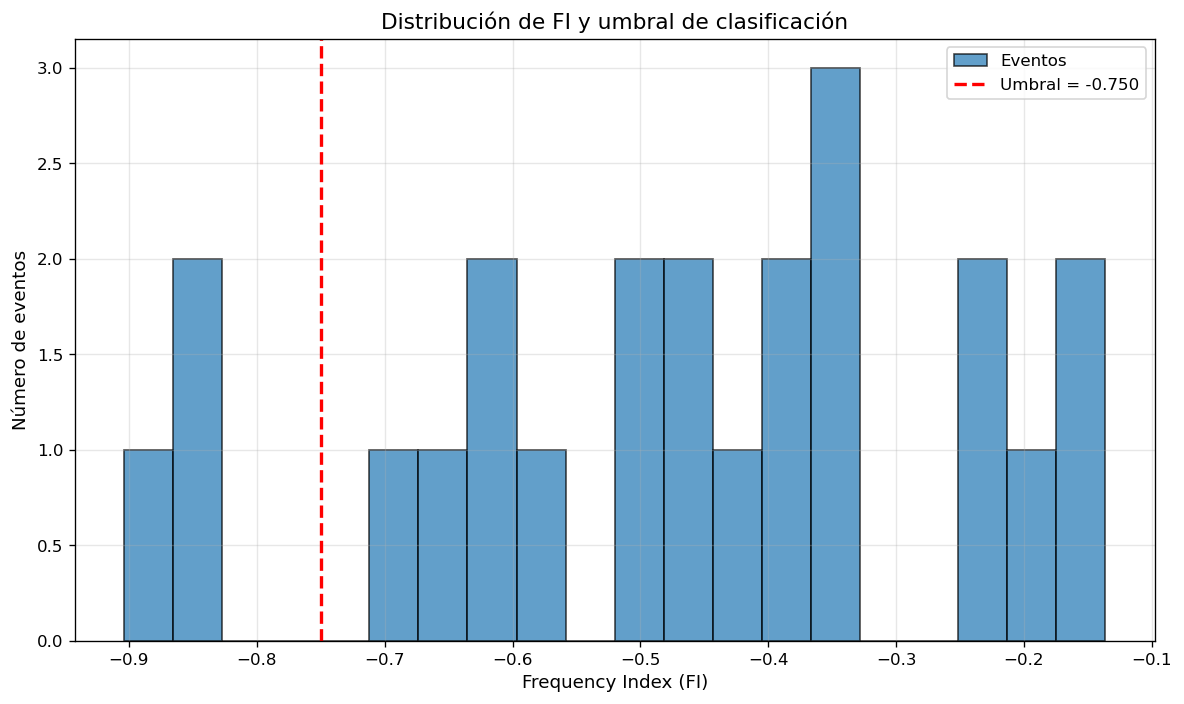

In [36]:
# 9. Visualización

# %%
fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(valid_df["fi"], bins=20, edgecolor="black", alpha=0.7, label="Eventos")
ax.axvline(threshold, color="red", linestyle="--", linewidth=2, label=f"Umbral = {threshold:.3f}")
ax.set_xlabel("Frequency Index (FI)")
ax.set_ylabel("Número de eventos")
ax.set_title("Distribución de FI y umbral de clasificación")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(PATHS["output_dir"] / "fi_histogram.png", dpi=150)
plt.show()


In [42]:
# 10. Guardar resultados conservando TODO el catálogo original
# ------------------------------------------------------------

fi_class_df = (
    valid_df[["event_id", "fi_class"]]
    .drop_duplicates(subset=["event_id"])
    .copy()
)

output = catalog.copy().merge(fi_class_df, on="event_id", how="left")

# opcional:
output["fi_class"] = output["fi_class"].fillna("NC")

output.to_csv(PATHS["output_csv"], index=False)

print(f"Resultados guardados en: {PATHS['output_csv']}")
print(f"Eventos clasificados: {output['fi_class'].notna().sum()} / {len(output)}")

Resultados guardados en: /home/elizabeth/soft/src/QuickQuake/data/merged/output/GAMMA_hypodd_catalog_qcfiltered_FI.csv
Eventos clasificados: 48 / 48


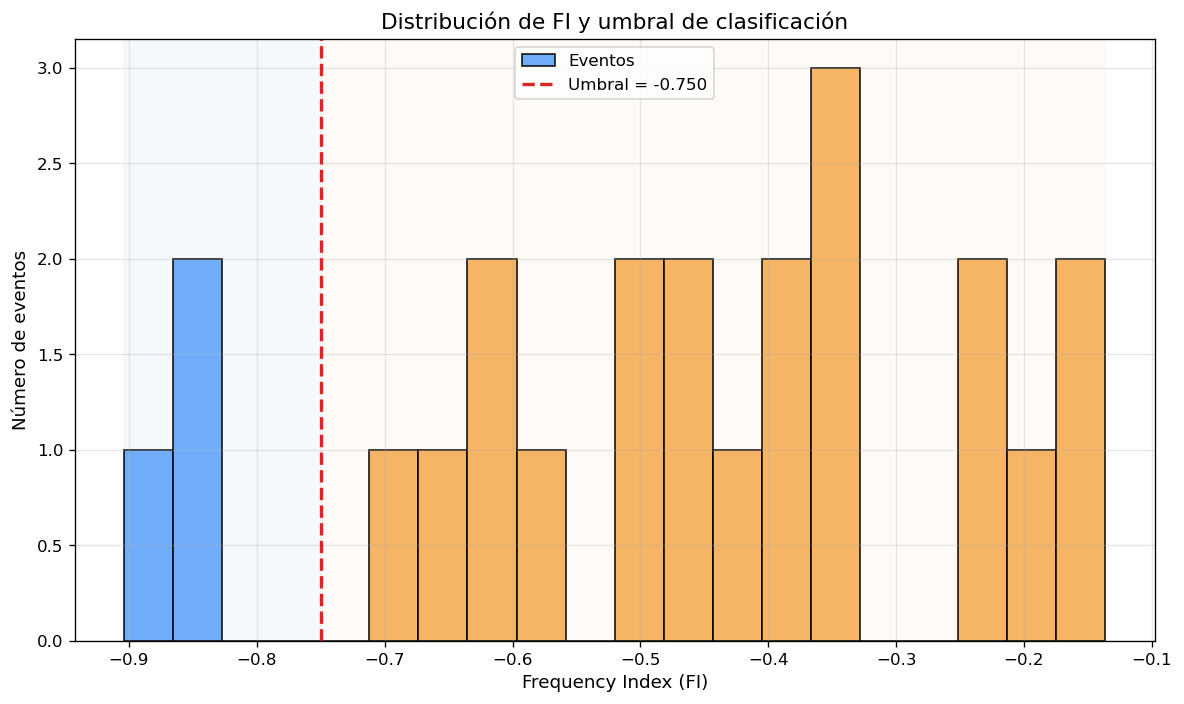

In [38]:
# 9. Visualización

fig, ax = plt.subplots(figsize=(10, 6))

fi_vals = valid_df["fi"].dropna().values

# Colores
LP_COLOR = "#60A5FA"   # azul más fuerte
VT_COLOR = "#F6AD55"   # naranja suave
THR_COLOR = "#DC2626"  # rojo threshold

# Histograma
counts, bins, patches = ax.hist(
    fi_vals,
    bins=20,
    edgecolor="black",
    linewidth=1.0,
    alpha=0.9,
    label="Eventos"
)

# Pintar cada barra según su posición respecto al threshold
for left, right, patch in zip(bins[:-1], bins[1:], patches):
    center = 0.5 * (left + right)
    if center < threshold:
        patch.set_facecolor(LP_COLOR)
    else:
        patch.set_facecolor(VT_COLOR)

# Línea del umbral
ax.axvline(
    threshold,
    color=THR_COLOR,
    linestyle="--",
    linewidth=2,
    label=f"Umbral = {threshold:.3f}"
)

# Opcional: fondo muy sutil
ax.axvspan(bins[0], threshold, color=LP_COLOR, alpha=0.06, zorder=0)
ax.axvspan(threshold, bins[-1], color=VT_COLOR, alpha=0.06, zorder=0)

# Formato
ax.set_xlabel("Frequency Index (FI)")
ax.set_ylabel("Número de eventos")
ax.set_title("Distribución de FI y umbral de clasificación")
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(PATHS["output_dir"] / "fi_histogram.png", dpi=150)
plt.show()

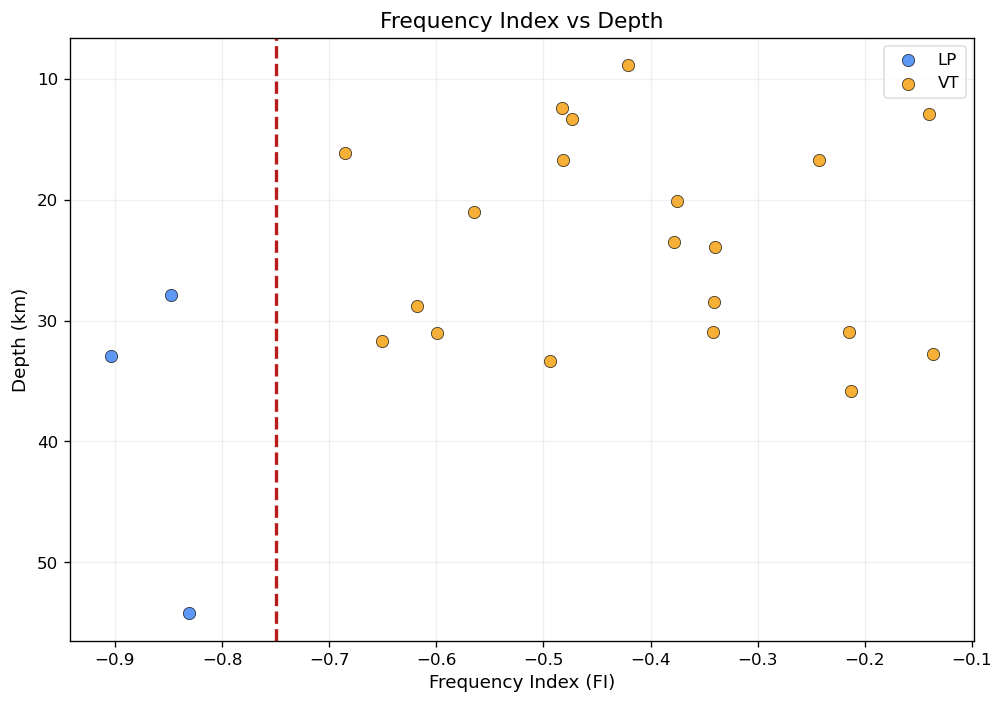

Saved depth figure to:
- /home/elizabeth/soft/src/QuickQuake/data/merged/output/fi_outputs/fi_vs_depth.png
- /home/elizabeth/soft/src/QuickQuake/data/merged/output/fi_outputs/fi_vs_depth.pdf


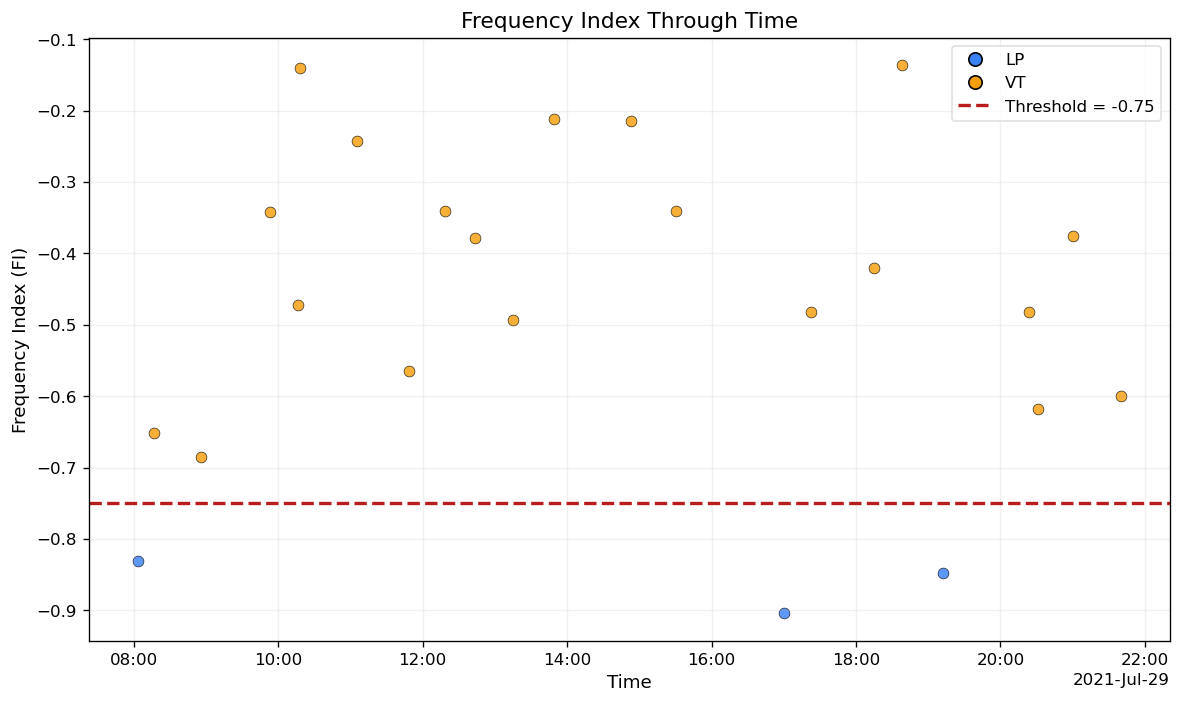

Saved time figure to:
- /home/elizabeth/soft/src/QuickQuake/data/merged/output/fi_outputs/fi_vs_time.png
- /home/elizabeth/soft/src/QuickQuake/data/merged/output/fi_outputs/fi_vs_time.pdf


In [39]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.lines import Line2D

# ------------------------------------------------------------
# CONFIGURACIÓN VISUAL
# ------------------------------------------------------------
LP_COLOR = "#3B82F6"      # azul elegante
VT_COLOR = "#F59E0B"      # naranja elegante
THR_COLOR = "#B91C1C"     # rojo oscuro
GRID_ALPHA = 0.18

plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
})

# ------------------------------------------------------------
# PREPARAR DATOS
# ------------------------------------------------------------
plot_df = valid_df.copy().sort_values("event_time").reset_index(drop=True)

if plot_df.empty:
    raise ValueError("valid_df está vacío. No hay eventos válidos para graficar.")

lp_df = plot_df[plot_df["fi_class"] == "LP"].copy()
vt_df = plot_df[plot_df["fi_class"] == "VT"].copy()

lp_count = len(lp_df)
vt_count = len(vt_df)

# ============================================================
# FIGURA 1: FI VS DEPTH
# ============================================================
fig_depth, ax_depth = plt.subplots(figsize=(8.5, 6))

if "event_depth_km" in plot_df.columns and plot_df["event_depth_km"].notna().any():
    if lp_count > 0:
        ax_depth.scatter(
            lp_df["fi"], lp_df["event_depth_km"],
            s=54, c=LP_COLOR, edgecolors="black", linewidth=0.45,
            alpha=0.82, label="LP"
        )

    if vt_count > 0:
        ax_depth.scatter(
            vt_df["fi"], vt_df["event_depth_km"],
            s=54, c=VT_COLOR, edgecolors="black", linewidth=0.45,
            alpha=0.82, label="VT"
        )

    ax_depth.axvline(threshold, color=THR_COLOR, linestyle="--", linewidth=2.0)
    ax_depth.set_xlabel("Frequency Index (FI)")
    ax_depth.set_ylabel("Depth (km)")
    ax_depth.set_title("Frequency Index vs Depth")
    ax_depth.grid(True, alpha=GRID_ALPHA)
    ax_depth.invert_yaxis()
    ax_depth.legend(frameon=True, facecolor="white", edgecolor="0.85")

else:
    ax_depth.text(
        0.5, 0.5, "No depth data available",
        transform=ax_depth.transAxes,
        ha="center", va="center", fontsize=12
    )
    ax_depth.set_title("Frequency Index vs Depth")
    ax_depth.grid(True, alpha=GRID_ALPHA)

plt.tight_layout()

depth_png = PATHS["output_dir"] / "fi_vs_depth.png"
depth_pdf = PATHS["output_dir"] / "fi_vs_depth.pdf"

fig_depth.savefig(depth_png, bbox_inches="tight")
fig_depth.savefig(depth_pdf, bbox_inches="tight")
plt.show()

print(f"Saved depth figure to:\n- {depth_png}\n- {depth_pdf}")


# ============================================================
# FIGURA 2: FI VS TIME
# ============================================================
fig_time, ax_time = plt.subplots(figsize=(10, 6))

if lp_count > 0:
    ax_time.scatter(
        lp_df["event_time"], lp_df["fi"],
        s=42, c=LP_COLOR, edgecolors="black", linewidth=0.4,
        alpha=0.82, label="LP"
    )

if vt_count > 0:
    ax_time.scatter(
        vt_df["event_time"], vt_df["fi"],
        s=42, c=VT_COLOR, edgecolors="black", linewidth=0.4,
        alpha=0.82, label="VT"
    )

ax_time.axhline(threshold, color=THR_COLOR, linestyle="--", linewidth=2.0)

ax_time.set_xlabel("Time")
ax_time.set_ylabel("Frequency Index (FI)")
ax_time.set_title("Frequency Index Through Time")
ax_time.grid(True, alpha=GRID_ALPHA)

locator = mdates.AutoDateLocator()
formatter = mdates.ConciseDateFormatter(locator)
ax_time.xaxis.set_major_locator(locator)
ax_time.xaxis.set_major_formatter(formatter)

legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor=LP_COLOR,
           markeredgecolor='black', markersize=8, label='LP'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor=VT_COLOR,
           markeredgecolor='black', markersize=8, label='VT'),
    Line2D([0], [0], color=THR_COLOR, linestyle='--', linewidth=2,
           label=f'Threshold = {threshold:.2f}')
]
ax_time.legend(handles=legend_elements, frameon=True, facecolor="white", edgecolor="0.85")

plt.tight_layout()

time_png = PATHS["output_dir"] / "fi_vs_time.png"
time_pdf = PATHS["output_dir"] / "fi_vs_time.pdf"

fig_time.savefig(time_png, bbox_inches="tight")
fig_time.savefig(time_pdf, bbox_inches="tight")
plt.show()

print(f"Saved time figure to:\n- {time_png}\n- {time_pdf}")